# HW3 DAI Shi Yang Alris 1155179724

Using the dataset logistic-regression-example-1:

Apply PCA to the feature data and vary the number of principal components r.
For each value of r, use the resulting r-dimensional features with their labels to train a logistic regression model to predict the outputs. Visualize the decesion boundary for r=2 case.
Evaluate the model using classification accuracy (numer of correct classification/ total data size).
Plot the accuracy as a function of r and briefly discuss how the performance changes with r.


Requirement: You may use existing Python libraries to perform the singular value decomposition (SVD) of matrices.  Perform SVD on X matrix rather than on covariance matrix directly.  Don't use ML libraries to perform the task.  Apart from that, you can copy and paste any codes from our examples.



Submit: codes, r=2 decesion boundary plot, the accuracy– r plot, and a short summary of your results.


Train set size: 614
Test set size: 154
r =  1: Train Acc = 0.7280, Test Acc = 0.6883
r =  2: Train Acc = 0.7068, Test Acc = 0.6883


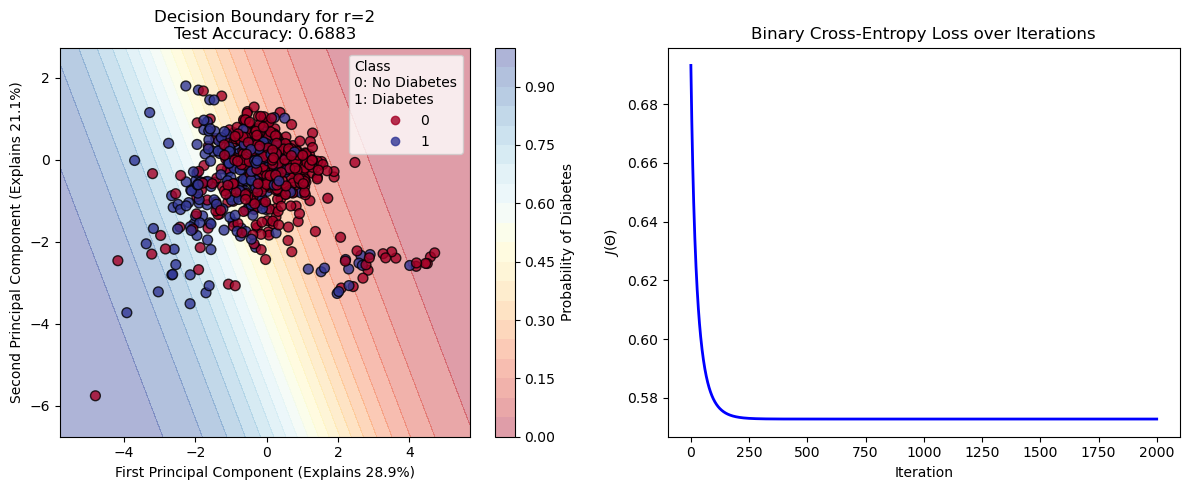

r =  3: Train Acc = 0.7280, Test Acc = 0.6948
r =  4: Train Acc = 0.7296, Test Acc = 0.7078
r =  5: Train Acc = 0.7524, Test Acc = 0.7338
r =  6: Train Acc = 0.7769, Test Acc = 0.7662
r =  7: Train Acc = 0.7866, Test Acc = 0.7597
r =  8: Train Acc = 0.7899, Test Acc = 0.7532


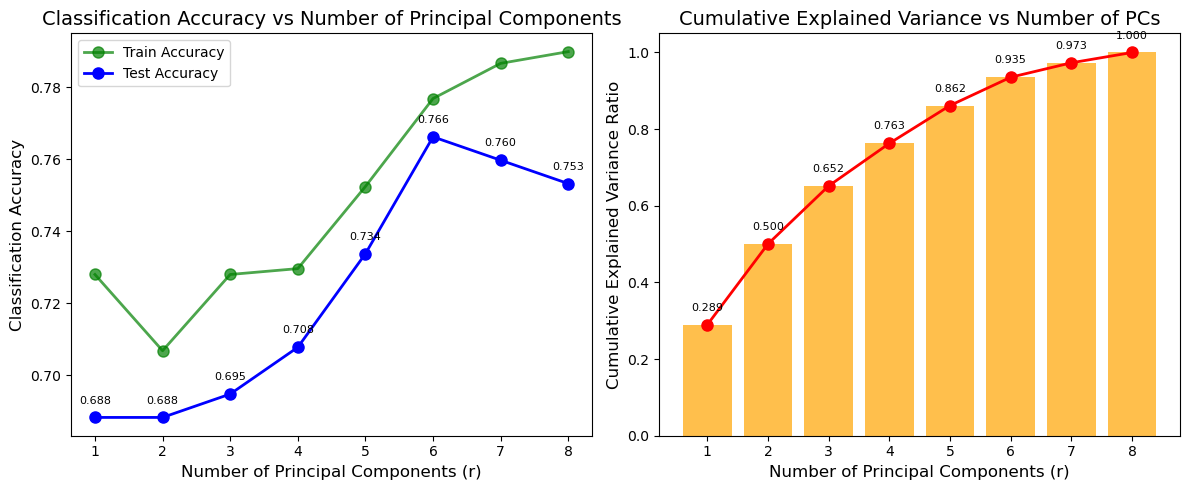


=== Optimal Number of Components ===
Best test accuracy: 0.7662 with r=6
At r=6, cumulative explained variance: 0.9354

=== Comparison ===
Full model (r = 8) accuracy: 0.7532
Best reduced model accuracy: 0.7662
Difference: 0.0130


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/User/Desktop/5061/examples/example_data/logistic-regression-example-1.csv")

X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values

from sklearn import preprocessing
scaler = preprocessing.RobustScaler()
X_scaled = scaler.fit_transform(X)
X_centered = X_scaled

def perform_pca(X, r):
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    V = Vt.T
    principal_components = V[:, :r]
    X_pca = X @ principal_components
    
    return X_pca, principal_components, s

class LogisticRegression:
    def __init__(self, alpha=0.01, n_iterations=1000):
        self.alpha = alpha
        self.n_iterations = n_iterations
        self.theta1 = None
        self.theta2 = 0
        self.loss_history = []
        
    def sigmoid(self, z):
        return (1 / (1 + np.exp(-z)))
    
    def computeCost(self, theta2, theta1, X, y):
        m = X.shape[0]
        predictions = self.sigmoid(X @ theta1 + theta2)
        cost = -(1/m) * (y.T.dot(np.log(predictions + 1e-15))+(1 - y).T.dot(np.log(1 - predictions + 1e-15)))

        return cost.flatten()[0]
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.theta1 = np.zeros(n_features)
        self.theta2 = 0
        self.loss_history = []
        
        for i in range(self.n_iterations):
            linear_model = X @ self.theta1 + self.theta2
            y_predicted = self.sigmoid(linear_model)
            self.loss_history.append(self.computeCost(self.theta2, self.theta1, X, y))
            
            dtheta1 = (1 / n_samples) * X.T @ (y_predicted - y)
            dtheta2 = (1 / n_samples) * np.sum(y_predicted - y)
            
            self.theta1 -= self.alpha * dtheta1
            self.theta2 -= self.alpha * dtheta2
            
    def predict(self, X):
        linear_model = X @ self.theta1 + self.theta2
        y_predicted = self.sigmoid(linear_model)
        return (y_predicted >= 0.5).astype(int)
    
    def predict_proba(self, X):
        linear_model = X @ self.theta1 + self.theta2
        return self.sigmoid(linear_model)

#creating traininng and test sets
np.random.seed(42)
indices = np.random.permutation(len(X))
train_size = int(0.8 * len(X))
train_idx, test_idx = indices[:train_size], indices[train_size:]

X_train, X_test = X_centered[train_idx], X_centered[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"\nTrain set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

n_features = X.shape[1]
max_r = n_features
accuracies = []
train_accuracies = []

for r in range(1, max_r + 1):
    # Apply PCA
    X_train_pca, components, singular_values = perform_pca(X_train, r)
    X_test_pca = X_test @ components
    
    lr_model = LogisticRegression(alpha=0.1, n_iterations=2000)

    lr_model.fit(X_train_pca, y_train)

    y_train_pred = lr_model.predict(X_train_pca)
    train_accuracy = np.mean(y_train_pred == y_train)
    
    y_test_pred = lr_model.predict(X_test_pca)
    test_accuracy = np.mean(y_test_pred == y_test)
    
    train_accuracies.append(train_accuracy)
    accuracies.append(test_accuracy)
    
    print(f"r = {r:2d}: Train Acc = {train_accuracy:.4f}, Test Acc = {test_accuracy:.4f}")
    
    if r == 2:
        x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
        y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

        Z = lr_model.predict_proba(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        plt.figure(figsize=(12, 5))
        
        plt.subplot(1, 2, 1)
        plt.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu', levels=20)
        plt.colorbar(label='Probability of Diabetes')

        scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], 
                             c=y_train, cmap='RdYlBu', edgecolor='black', 
                             s=50, alpha=0.8)
        plt.xlabel(f'First Principal Component (Explains {singular_values[0]**2/np.sum(singular_values**2)*100:.1f}%)')
        plt.ylabel(f'Second Principal Component (Explains {singular_values[1]**2/np.sum(singular_values**2)*100:.1f}%)')
        plt.title(f'Decision Boundary for r=2\nTest Accuracy: {test_accuracy:.4f}')
        plt.legend(*scatter.legend_elements(), title="Class\n0: No Diabetes\n1: Diabetes")
        
        plt.subplot(1, 2, 2)
        plt.plot(lr_model.loss_history, 'b-', linewidth=2)
        plt.xlabel('Iteration')
        plt.ylabel('$J(\Theta)$')
        plt.title('Binary Cross-Entropy Loss over Iterations')
        
        plt.tight_layout()
        plt.show()


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, max_r + 1), train_accuracies, 'go-', linewidth=2, markersize=8, label='Train Accuracy', alpha=0.7)
plt.plot(range(1, max_r + 1), accuracies, 'bo-', linewidth=2, markersize=8, label='Test Accuracy')
plt.xlabel('Number of Principal Components (r)', fontsize=12)
plt.ylabel('Classification Accuracy', fontsize=12)
plt.title('Classification Accuracy vs Number of Principal Components', fontsize=14)
plt.xticks(range(1, max_r + 1))
plt.legend()

for i, acc in enumerate(accuracies):
    plt.annotate(f'{acc:.3f}', (i+1, acc), textcoords="offset points", 
                 xytext=(0,10), ha='center', fontsize=8)

plt.subplot(1, 2, 2)
cumulative_variance = np.cumsum(singular_values**2) / np.sum(singular_values**2)
plt.bar(range(1, max_r + 1), cumulative_variance, color='orange', alpha=0.7)
plt.plot(range(1, max_r + 1), cumulative_variance, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Number of Principal Components (r)', fontsize=12)
plt.ylabel('Cumulative Explained Variance Ratio', fontsize=12)
plt.title('Cumulative Explained Variance vs Number of PCs', fontsize=14)
plt.xticks(range(1, max_r + 1))
plt.ylim([0, 1.05])


for i, var in enumerate(cumulative_variance):
    plt.annotate(f'{var:.3f}', (i+1, var), textcoords="offset points", 
                 xytext=(0,10), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

best_r = np.argmax(accuracies) + 1
print(f"\n=== Optimal Number of Components ===")
print(f"Best test accuracy: {max(accuracies):.4f} with r={best_r}")
print(f"At r={best_r}, cumulative explained variance: {cumulative_variance[best_r-1]:.4f}")


print(f"\n=== Comparison ===")
print(f"Full model (r = {max_r}) accuracy: {accuracies[-1]:.4f}")
print(f"Best reduced model accuracy: {max(accuracies):.4f}")
print(f"Difference: {max(accuracies) - accuracies[-1]:.4f}")


## Summary (briefly discuss how the performance changes with r)

The number of principle components have been evaluated. In the training set, the highest classification accuracy contains 8 prinicple components with training accuracy of 0.7899. However, for the testing set, the classification accuracy does not increase with the number of principle components. the best test accuracy is with r = 6, with mclassification accuracy of 0.7662. 
